Couple_zodiac
Pisces_Virgo           80
Scorpio_Virgo          77
Sagittarius_Virgo      77
Gemini_Taurus          76
Pisces_Scorpio         76
                       ..
Taurus_Taurus          30
Aries_Aries            30
Leo_Leo                30
Gemini_Gemini          26
Capricorn_Capricorn    23
Name: count, Length: 78, dtype: int64


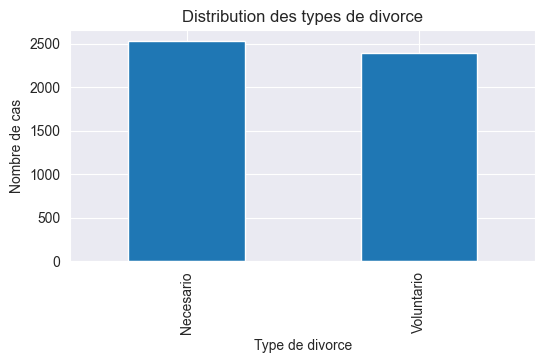

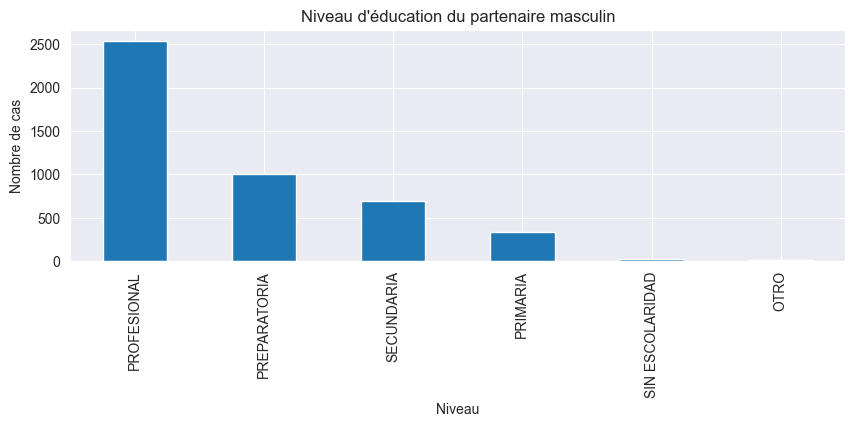

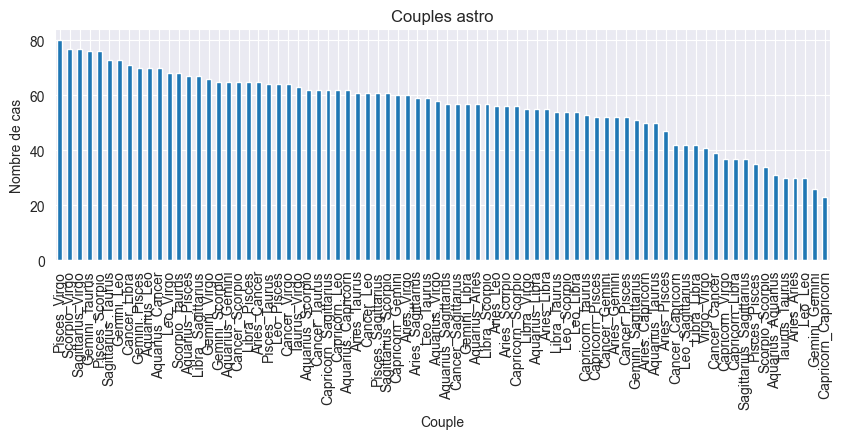

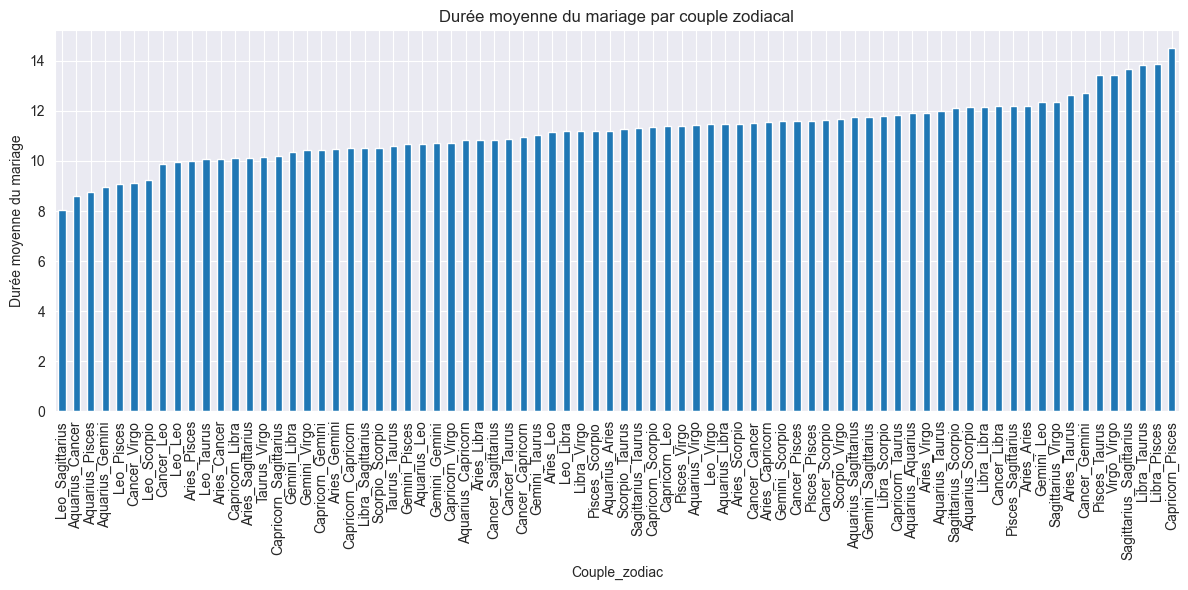

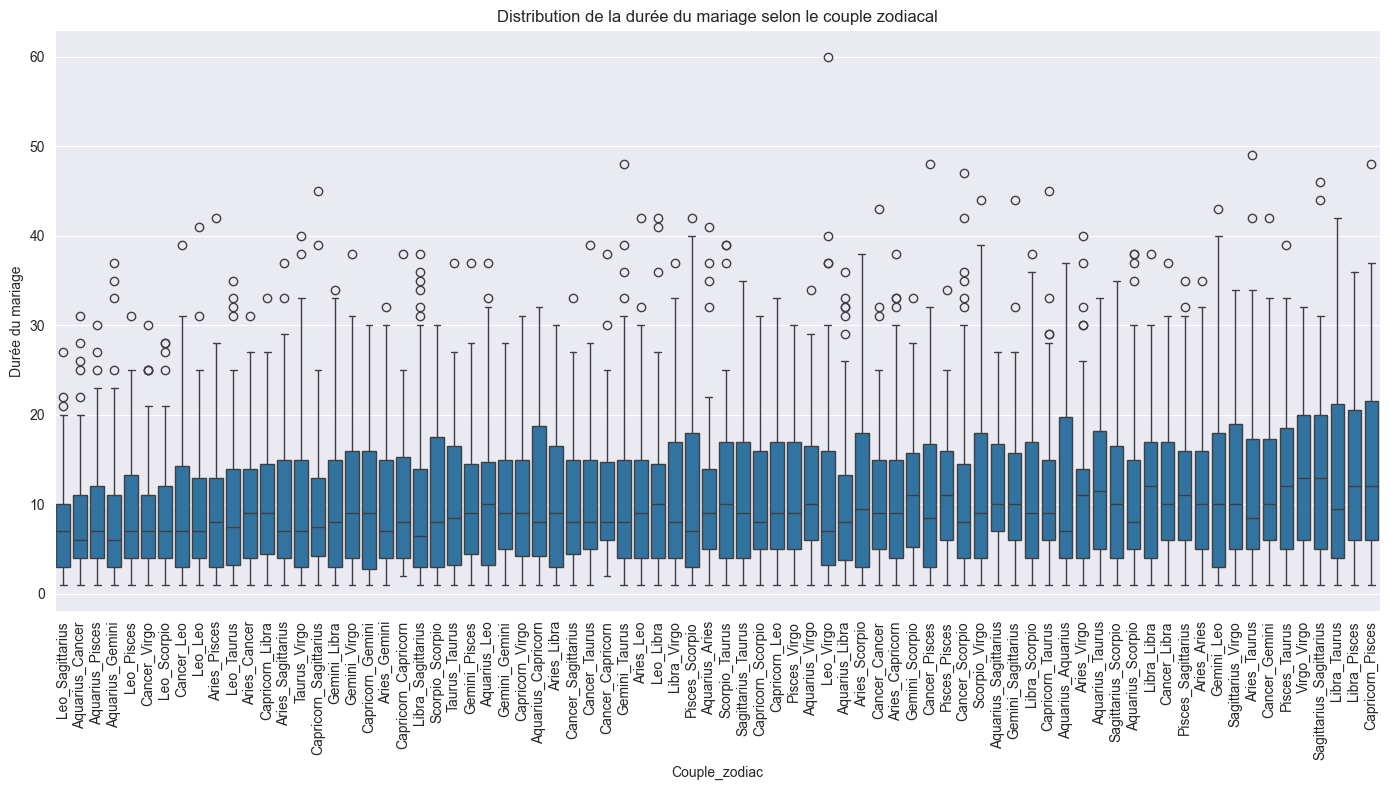

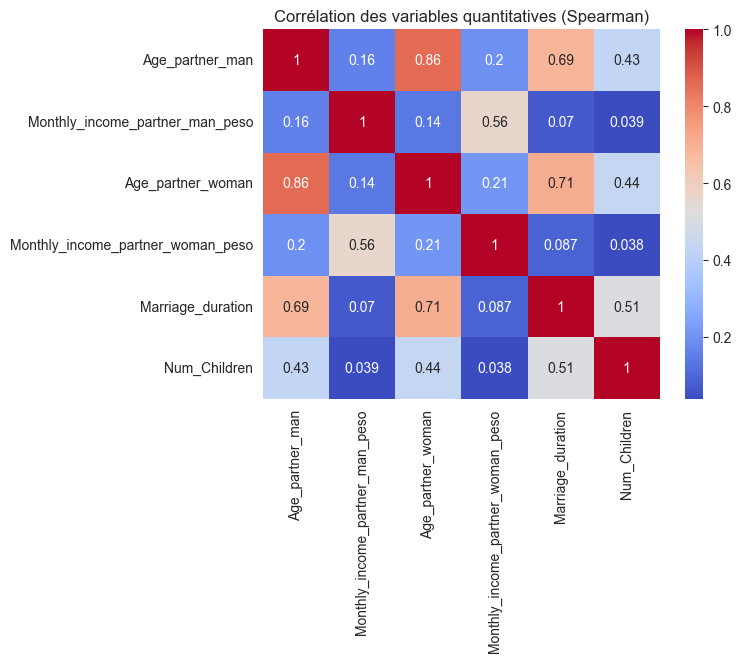

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score, KFold


df = pd.read_csv("data/divorces_2000-2015_translated.csv")

def zodiac_from_date(date_str):
    try:
        # gestion pd.NaT et floats (manquants)
        if pd.isnull(date_str):
            return None
        # conversion forcée (dayfirst pour J/M/AAAA)
        date = pd.to_datetime(date_str, dayfirst=True, errors='coerce')
        if pd.isnull(date):
            return None
        day = date.day
        month = date.month
        # Zodiaque
        zodiac_dates = [
            ((1, 20), (2, 18), "Aquarius"),
            ((2, 19), (3, 20), "Pisces"),
            ((3, 21), (4, 19), "Aries"),
            ((4, 20), (5, 20), "Taurus"),
            ((5, 21), (6, 20), "Gemini"),
            ((6, 21), (7, 22), "Cancer"),
            ((7, 23), (8, 22), "Leo"),
            ((8, 23), (9, 22), "Virgo"),
            ((9, 23), (10, 22), "Libra"),
            ((10, 23), (11, 21), "Scorpio"),
            ((11, 22), (12, 21), "Sagittarius"),
            ((12, 22), (1, 19), "Capricorn"),
        ]
        for start, end, sign in zodiac_dates:
            sm, sd = start
            em, ed = end
            if (month == sm and day >= sd) or (month == em and day <= ed):
                return sign
        if (month == 12 and day >= 22) or (month == 1 and day <= 19):
            return "Capricorn"
        return None
    except Exception:
        return None

def couple_zodiac(s1, s2):
    # gère valeurs manquantes avec tri
    if pd.isnull(s1) or pd.isnull(s2):
        return None
    return "_".join(sorted([s1, s2]))



#transformation des colonnes
df['Zodiac_partner_man'] = df['DOB_partner_man'].apply(zodiac_from_date)
df['Zodiac_partner_woman'] = df['DOB_partner_woman'].apply(zodiac_from_date)
df['Couple_zodiac'] = df.apply(lambda row: couple_zodiac(row['Zodiac_partner_man'], row['Zodiac_partner_woman']), axis=1)
print(df['Couple_zodiac'].value_counts())


# Distribution des types de divorce
plt.figure(figsize=(6,3))
df['Type_of_divorce'].value_counts().plot(kind='bar')
plt.title("Distribution des types de divorce")
plt.xlabel("Type de divorce")
plt.ylabel("Nombre de cas")
plt.show()


# Distribution du niveau d'éducation (partenaire homme)
plt.figure(figsize=(10,3))
df['Level_of_education_partner_man'].value_counts().plot(kind='bar')
plt.title("Niveau d'éducation du partenaire masculin")
plt.xlabel("Niveau")
plt.ylabel("Nombre de cas")
plt.show()

# Distribution des couples en signes astro
plt.figure(figsize=(10,3))
df['Couple_zodiac'].value_counts().plot(kind='bar')
plt.title("Couples astro")
plt.xlabel("Couple")
plt.ylabel("Nombre de cas")
plt.show()

# Distribution des durées moyenne de marriage par couples de signes astro
grouped = df.groupby('Couple_zodiac')['Marriage_duration'].mean().sort_values()

plt.figure(figsize=(12,6))
grouped.plot(kind='bar')
plt.ylabel("Durée moyenne du mariage")
plt.title("Durée moyenne du mariage par couple zodiacal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14,8))
sns.boxplot(x="Couple_zodiac", y="Marriage_duration", data=df, order=grouped.index)
plt.ylabel("Durée du mariage")
plt.title("Distribution de la durée du mariage selon le couple zodiacal")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Corrélation entre variables quantitatives
quant_vars = ['Age_partner_man','Monthly_income_partner_man_peso','Age_partner_woman','Monthly_income_partner_woman_peso','Marriage_duration','Num_Children']
corr_matrix = df[quant_vars].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Corrélation des variables quantitatives (Spearman)")
plt.show()





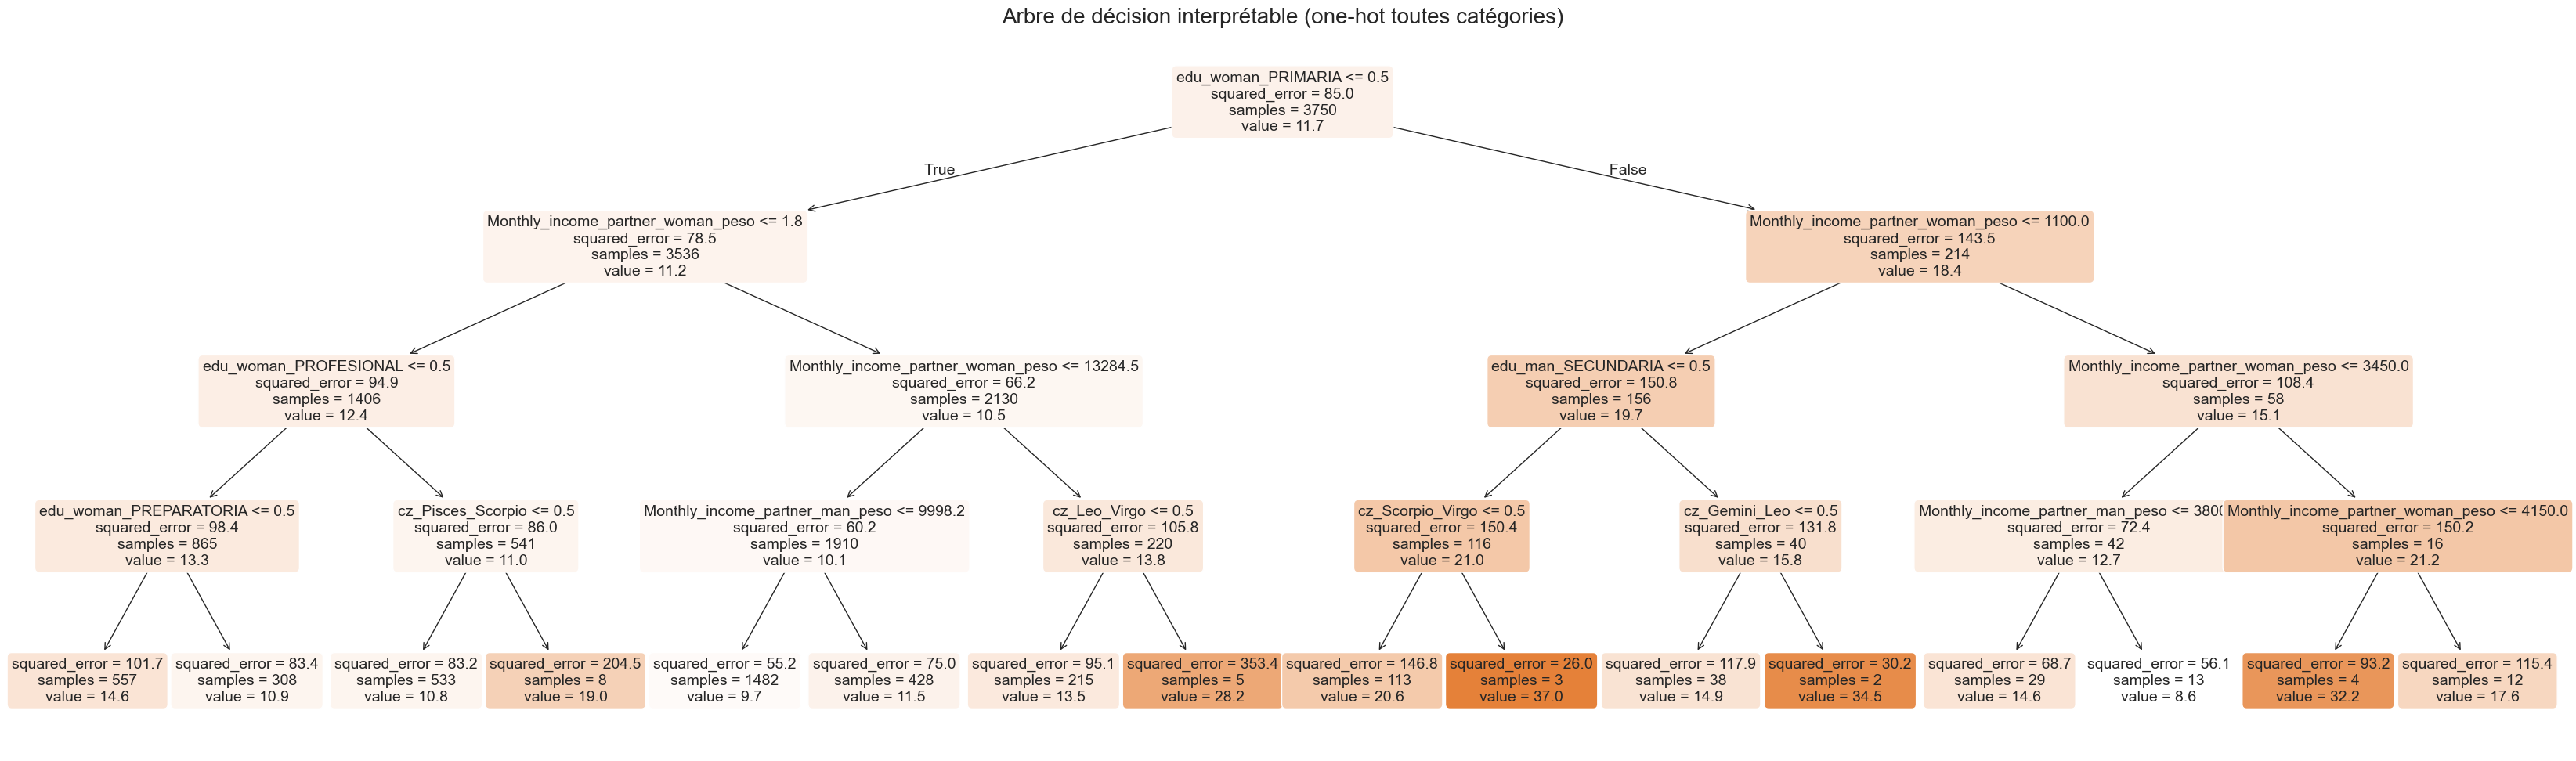

edu_woman_PRIMARIA                   0.365856
Monthly_income_partner_woman_peso    0.286826
edu_woman_PREPARATORIA               0.097029
edu_woman_PROFESIONAL                0.062761
Monthly_income_partner_man_peso      0.051414
cz_Leo_Virgo                         0.036853
edu_man_SECUNDARIA                   0.027855
cz_Scorpio_Virgo                     0.027471
cz_Gemini_Leo                        0.025598
cz_Pisces_Scorpio                    0.018335
dtype: float64


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Encodage one-hot des variables catégorielles
X = pd.concat([
    pd.get_dummies(df['Level_of_education_partner_man'], prefix='edu_man'),
    pd.get_dummies(df['Level_of_education_partner_woman'], prefix='edu_woman'),
    df[['Monthly_income_partner_man_peso', 'Monthly_income_partner_woman_peso']].fillna(0),
    pd.get_dummies(df['Couple_zodiac'], prefix='cz')
], axis=1)

# Variable cible (durée du mariage en années)
y = df['Marriage_duration']

# Retirer les lignes avec NaN dans la cible
mask = y.notnull()
X_clean = X[mask]
y_clean = y[mask]

# Split apprentissage/test
X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

# Arbre de régression
reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_train)

plt.figure(figsize=(42,12))
plot_tree(
    reg,
    feature_names=X_clean.columns,
    filled=True,
    rounded=True,
    fontsize=14,
    precision=1
)
plt.title("Arbre de décision interprétable (one-hot toutes catégories)", fontsize=20)
plt.show()

# Importance des variables
importances = pd.Series(reg.feature_importances_, index=X_clean.columns).sort_values(ascending=False)
print(importances[importances > 0])  # Affiche les variables ayant un impact

